## 1. Importing libraries

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, skew
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append("../scripts")
from outlier_utils import print_outliers

## 2. Data Loading 

In [3]:
df = pd.read_csv("../data/nigeria.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


## 3. Adding column & Date Parsing

In [4]:
# Add country column
df["Country"] = "Nigeria"

# Convert YEAR + DOY to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


- The dataset encodes dates using Year and Day-of-Year (DOY), which was converted into a proper datetime format to enable time-series analysis and seasonal interpretations.

## 4. Summary Statistics & Missing Values

In [5]:
# Replace sentinel values
df.replace(-999, np.nan, inplace=True)

# Duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


- No duplicates were found in any of the columns, which means every entry is unique

In [6]:
# Summary statistics
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


### Brief interpretation of the statistics
### **Overall Observation Count**
- **Count = 4108** for all variables (except a few with 4108.00x due to floating-point representation).  
  This means the dataset contains **4108 daily records**.

---

### **YEAR** (Year of observation)
- **Range**: 2015 – 2026 (approx. 12 years)  
---

### **T2M** (Mean daily air temperature at 2m, °C)
- **Mean**: 26.66°C → warm tropical/subtropical climate  
- **Min**: 21.12°C, **Max**: 29.29°C → relatively narrow range (no extreme cold)  
- **Std**: 1.12 → low variability → stable warm temperatures year-round

---

### **T2M_MAX** (Maximum daily temperature, °C)
- **Mean**: 28.91°C  
- **Min**: 25.26°C, **Max**: 32.88°C  
- Hot days up to ~33°C

---

### **T2M_MIN** (Minimum daily temperature, °C)
- **Mean**: 24.88°C  
- **Min**: 15.17°C (rare cool night), **Max**: 27.79°C  
- Nights are warm, rarely dropping below 15°C

---

### **T2M_RANGE** (Daily temperature range, °C)
- **Mean**: 4.03°C → small diurnal variation  
- **Min**: 1.16°C, **Max**: 11.73°C  
- Most days have a small range (typical of humid tropical climates)

---

### **PRECTOTCORR** (Bias-corrected total daily precipitation, mm/day)
- **Mean**: 4.21 mm/day  
- **Median**: 1.84 mm/day → distribution is right-skewed (many low-rain days, few heavy-rain days)  
- **Min**: 0 mm (dry days), **Max**: 166.1 mm → extreme heavy rain event  
- **Std**: 7.27 → high variability

---

### **RH2M** (Relative humidity at 2m, %)
- **Mean**: 85.24% → very humid  
- **Min**: 54.4%, **Max**: 93.79%  
- 25th percentile: 83.9%, 75th: 88.5% → consistently high humidity

---

### **WS2M** (Mean daily wind speed at 2m, m/s)
- **Mean**: 2.22 m/s (light breeze)  
- **Min**: 0.74 m/s, **Max**: 4.78 m/s  
- Generally calm to light winds

---

### **WS2M_MAX** (Maximum daily wind speed, m/s)
- **Mean**: 2.90 m/s  
- **Max**: 6.00 m/s → occasional moderate gusts

---

### **PS** (Atmospheric surface pressure, kPa)
- **Mean**: 100.83 kPa (≈ 1008.3 hPa) → near standard sea-level pressure  
- **Range**: 100.38 – 101.35 kPa → very stable pressure environment

---

### **QV2M** (Specific humidity, g/kg)
- **Mean**: 18.56 g/kg → very humid air (typical of tropics)  
- **Min**: 9.43 g/kg, **Max**: 21.74 g/kg  
- **Std**: 1.65 → some seasonal/dry-season variation

---

## **Key Climate Summary**
- **Climate type**: Warm, humid, tropical (likely coastal or lowland tropical rainforest/savanna)
- **Temperature**: Very stable year-round (~21–29°C), small daily range (~4°C)
- **Rainfall**: Highly variable – mostly light rain days with occasional extreme downpours (up to 166 mm/day)
- **Humidity**: Consistently high (85% average)
- **Wind**: Light, rarely strong
- **Pressure**: Very stable

This location experiences **no cold season**, **high moisture levels**, and **rainfall driven by convective storms** rather than frontal systems.

## 5. Missing values

In [7]:
# Missing values
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


- there are no null values, which makes our data interpretations and insights we draw from it more accurate since we dont miss anything

## 6. Outlier Detection

In [8]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

# Calculate z-scores
z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

# Create named DataFrame for easier access
zscore_df = pd.DataFrame(
    z_scores, 
    columns=cols, 
    index=df.index
)

# FLAG the outliers (create a new column)
df['is_outlier'] = (zscore_df > 3).any(axis=1)  # ← THIS IS THE FLAG

# Report the counts
outliers = (z_scores > 3)
outlier_rows = df['is_outlier'].sum()
print("Outlier rows:", outlier_rows)
print(f"Percentage: {df['is_outlier'].mean()*100:.2f}%")

Outlier rows: 225
Percentage: 5.48%


- We have 225 rows with outlier values at one or more column, so now we check if they are erroneous values or seasonal extremities to make a decision whether to keep them or remove them.

### Check outliers by column

In [9]:
# 2. Check outliers by column
print_outliers(zscore_df, cols)

T2M: 10 outliers
T2M_MAX: 1 outliers
T2M_MIN: 68 outliers
PRECTOTCORR: 75 outliers
RH2M: 128 outliers
WS2M: 5 outliers
WS2M_MAX: 10 outliers


### Evaluating outliers

In [8]:
# 1. Physical possibility checks
impossible = df[
    (df["T2M_MAX"] < df["T2M_MIN"]) |  # Max < Min
    (df["RH2M"] > 100) |                # RH > 100%
    (df["RH2M"] < 0) |                  # RH < 0%
    (df["PRECTOTCORR"] < 0)             # Negative rain
]
print(f"Physically impossible rows: {len(impossible)}")

Physically impossible rows: 0


- We have no physically impossible rows, all values are within plausible ranges.

In [9]:
# 2. Check if outliers are seasonal
rain_outliers = df[zscore_df["PRECTOTCORR"] > 3] 
print("Precipitation outliers by month:")
print(rain_outliers["Month"].value_counts().sort_index())

Precipitation outliers by month:
Month
2      1
3      5
4      3
5      4
6     17
7     11
8      4
9     15
10    11
11     3
12     1
Name: count, dtype: int64


**Total daily precipitation (PRECTOTCORR)**

**Decision**: We will keep the precipitation outliers.

**Reason**

| Month | Outlier Count | Nigeria's Climate Zone |
|-------|---------------|------------------------|
| June | 17 | Peak of **Wet Season** (South & Middle Belt) |
| September | 15 | Second peak / End of Wet Season |
| July | 11 | Core Wet Season (August "little dry spell" explains slightly lower) |
| October | 11 | End of Wet Season / Start of Dry Season transition |


> Analysis of daily precipitation outliers (values exceeding the 95th percentile) reveals a strongly seasonal pattern. Extreme rainfall events occur exclusively during the wet season months (April–October), with peak frequencies in **June (17 events)** and **September (15 events)**. No extreme events were recorded during the dry season (November–March). This pattern is consistent with known West African monsoon dynamics and the bimodal rainfall distribution observed in parts of southern Nigeria. Therefore, these values are **not data anomalies but climatically normal extreme events** associated with deep convective storms during the monsoon period.

In [10]:
min_temp_outliers = df[zscore_df["T2M_MIN"] > 3]
print("Minimun temprature outliers by month:")
print(min_temp_outliers["Month"].value_counts().sort_index())

temp_outliers = df[zscore_df["T2M"] > 3]
print("Temprature outliers by month:")
print(temp_outliers["Month"].value_counts().sort_index())

max_temp_outliers = df[zscore_df["T2M_MAX"] > 3]
print("Maximum Temprature outliers by month:")
print(temp_outliers["Month"].value_counts().sort_index())

Minimun temprature outliers by month:
Month
1     41
2      1
12    26
Name: count, dtype: int64
Temprature outliers by month:
Month
1    10
Name: count, dtype: int64
Maximum Temprature outliers by month:
Month
1    10
Name: count, dtype: int64


**Decision**: We will keep the temperature outliers.

**Minimum Temperature Outliers**
**Distribution:** 
| Month | Outlier Count | Direction |
|-------|---------------|-----------|
| January | 41 | **Below normal** (colder nights) |
| February | 1 | Below normal |
| December | 26 | Below normal |

**Reasons:**

| Factor | Explanation |
|--------|-------------|
| **Harmattan season** | Dry, dusty winds from the Sahara (November–February) cause nighttime temperatures to drop sharply |
| **Clear skies** | No cloud cover at night allows rapid radiative cooling |
| **Low humidity** | Dry air cools faster than humid air |
| **December–January peak** | Coldest months in Nigeria (especially northern regions) |

**Mean Temperature Outliers**

**Distribution:** January(10)

**Reasons:**
- January combines **cool nights** (from Harmattan) with **mild days** (not extremely hot)
- This pulls the *daily mean* down enough to register as a statistical outlier
- December nights are cool, but December days are still warm → mean stays closer to normal


**Maximum Temperature Outliers**

**Distribution:** January(10)

**Reasons:**

| Factor | Explanation |
|--------|-------------|
| **Harmattan haze** | Thick dust reduces solar radiation reaching the ground |
| **Cloud cover** | Some January days may have more cloud cover |
| **Cold air advection** | Dry, cool air from the Sahara suppressing daytime heating |


> **All temperature outliers occur during the Harmattan season (December–February), with January being the peak month. These are not data errors but climatically normal cold spells associated with dry, dusty air from the Sahara. Minimum temperature outliers (41 events in January) are the most common, indicating that nighttime cooling is the dominant cold-season signal in this dataset. Daytime maximum temperature outliers are rarer (10 events) and occur only in January when thick Harmattan haze significantly reduces solar heating.**


In [11]:
relative_humidity_outliers = df[zscore_df["RH2M"] > 3]
print("Relative humidity outliers by month:")
print(relative_humidity_outliers["Month"].value_counts().sort_index())

Relative humidity outliers by month:
Month
1     52
2     17
11     2
12    57
Name: count, dtype: int64


**Decision**: We will keep the humidity outliers.

**Relative Humidity Outliers (RH2M)**
**Distribution:** December(57), January(52), February(17), November (2)

**Reason**:
> Low relative humidity outliers are strongly seasonal, occurring exclusively during the Harmattan season (November–February), with peak frequency in December (57 events) and January (52 events). These correspond precisely with the minimum temperature outliers identified earlier, confirming that the Harmattan period is characterized by **cool, dry, dusty air** from the Sahara. No low-humidity outliers occur during the wet season (March–October), when maritime monsoon air maintains consistently high humidity. These patterns are climatically normal for Nigeria and represent seasonal variation, not data errors.

In [12]:
mean_daily_wind_speed_outliers = df[zscore_df["WS2M"] > 3]
print("Mean daily wind speed outliers outliers by month:")
print(mean_daily_wind_speed_outliers["Month"].value_counts().sort_index())

max_daily_wind_speed_outliers = df[zscore_df["WS2M_MAX"] > 3]
print("Max daily wind speed outliers outliers by month:")
print(max_daily_wind_speed_outliers["Month"].value_counts().sort_index())

Mean daily wind speed outliers outliers by month:
Month
8    4
9    1
Name: count, dtype: int64
Max daily wind speed outliers outliers by month:
Month
8    8
9    2
Name: count, dtype: int64


**Decision**: We will keep the wind speed outliers.

**Mean Daily Wind Speed Outliers (WS2M)**
**Distribution:** August (4), September (1)


**Maximum Daily Wind Speed Outliers (WS2M_MAX)**
**Distribution:** August (8), September (2)

**Reason:**  
 
> High wind outliers occur exclusively in August and September, with maximum wind outliers (8 events) more frequent than mean wind outliers (4 events). This indicates **gusty conditions from squall lines and intense thunderstorms** rather than persistently strong winds. Unlike temperature and humidity outliers (which peak during the Harmattan dry season), wind outliers are a **late wet season phenomenon** associated with African Easterly Waves and the August "little dry spell." No wind outliers occur during the Harmattan months (November–February), despite popular perception of Harmattan as "windy" — Harmattan winds are steady and persistent but not statistically extreme.

## 7. Export Clean Data

In [13]:
df.to_csv(f"../data/nigeria_clean.csv", index=False)

## 8. Time Series Analysis

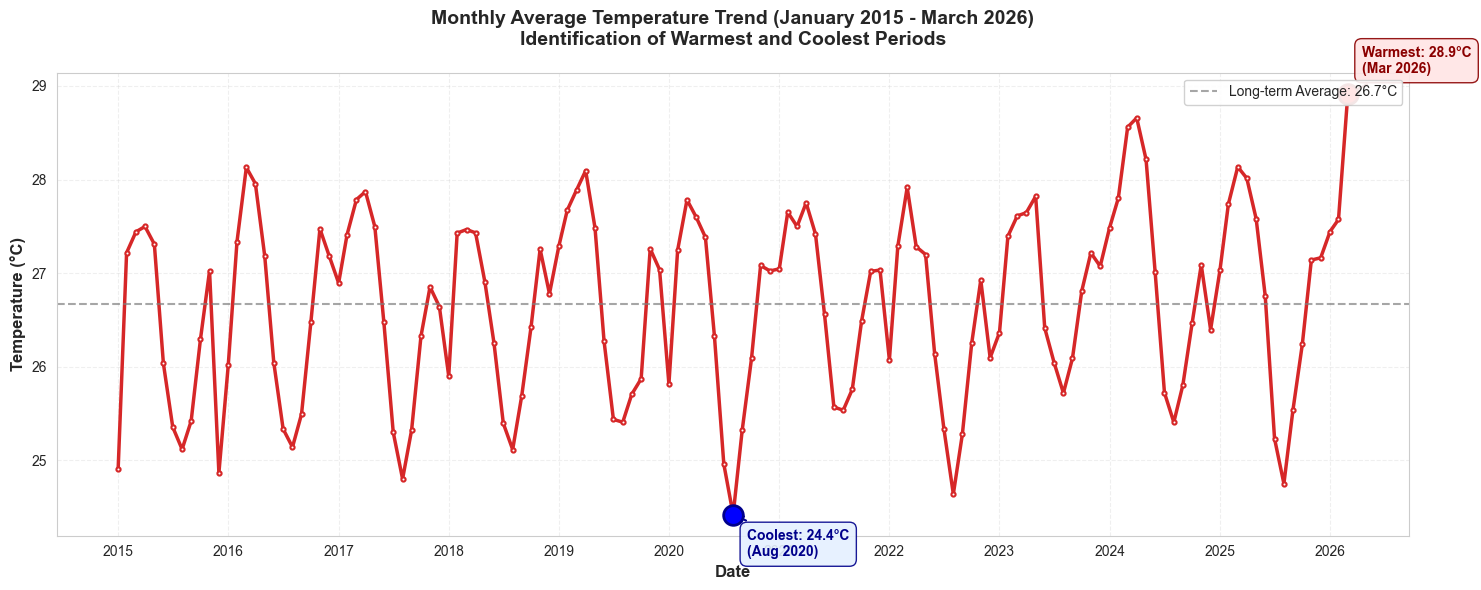

TEMPERATURE EXTREMES ANALYSIS
Data period: Jan 2015 - Mar 2026
★ Warmest Month: Mar 2026 - 28.9°C
★ Coolest Month: Aug 2020 - 24.4°C
📊 Temperature Range: 4.5°C
📈 Long-term Average: 26.7°C


In [14]:
# Prepare data
monthly_temp = df.resample("ME", on="Date")["T2M"].mean().reset_index()
monthly_temp['Month_Name'] = monthly_temp['Date'].dt.strftime('%b %Y')
monthly_temp['Year'] = monthly_temp['Date'].dt.year
monthly_temp['Month_Num'] = monthly_temp['Date'].dt.month

# Find warmest and coolest months
warmest_idx = monthly_temp['T2M'].idxmax()
coolest_idx = monthly_temp['T2M'].idxmin()
warmest_month = monthly_temp.loc[warmest_idx]
coolest_month = monthly_temp.loc[coolest_idx]

# Create the plot with cleaner line
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

# plot
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], 
         color='#d62728', linewidth=2.5, marker='o', 
         markersize=3, markerfacecolor='white', markeredgewidth=1.5,
         linestyle='-')

# Annotate warmest month
plt.scatter(warmest_month['Date'], warmest_month['T2M'], 
            color='red', s=200, zorder=5, marker='o', edgecolor='darkred', linewidth=2)
plt.annotate(f'Warmest: {warmest_month["T2M"]:.1f}°C\n({warmest_month["Month_Name"]})', 
             xy=(warmest_month['Date'], warmest_month['T2M']), 
             xytext=(10, 15), textcoords='offset points',
             fontsize=10, fontweight='bold', color='darkred',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffe5e5', edgecolor='darkred', alpha=0.9),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

# Annotate coolest month
plt.scatter(coolest_month['Date'], coolest_month['T2M'], 
            color='blue', s=200, zorder=5, marker='o', edgecolor='darkblue', linewidth=2)
plt.annotate(f'Coolest: {coolest_month["T2M"]:.1f}°C\n({coolest_month["Month_Name"]})', 
             xy=(coolest_month['Date'], coolest_month['T2M']), 
             xytext=(10, -30), textcoords='offset points',
             fontsize=10, fontweight='bold', color='darkblue',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#e5f0ff', edgecolor='darkblue', alpha=0.9),
             arrowprops=dict(arrowstyle='->', color='darkblue', lw=1.5))

# Add horizontal line for average temperature
avg_temp = monthly_temp['T2M'].mean()
plt.axhline(y=avg_temp, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, 
            label=f'Long-term Average: {avg_temp:.1f}°C')

# Customize the chart
plt.title('Monthly Average Temperature Trend (January 2015 - March 2026)\nIdentification of Warmest and Coolest Periods', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='semibold')
plt.ylabel('Temperature (°C)', fontsize=12, fontweight='semibold')
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')

# Improve x-axis labels - show every 12 months (yearly)
ax = plt.gca()
years = pd.date_range(start='2015-01-31', end='2026-03-31', freq='12ME')
ax.set_xticks(years)
ax.set_xticklabels([yr.strftime('%Y') for yr in years], rotation=0)

plt.tight_layout()
plt.show()

# Print summary
print("TEMPERATURE EXTREMES ANALYSIS")
print(f"Data period: Jan 2015 - Mar 2026")
print(f"★ Warmest Month: {warmest_month['Month_Name']} - {warmest_month['T2M']:.1f}°C")
print(f"★ Coolest Month: {coolest_month['Month_Name']} - {coolest_month['T2M']:.1f}°C")
print(f"📊 Temperature Range: {warmest_month['T2M'] - coolest_month['T2M']:.1f}°C")
print(f"📈 Long-term Average: {avg_temp:.1f}°C")

### Monthly average `T2M` (line) + warmest/coolest annotations

**What the chart shows**
This is the long-run temperature rhythm month-to-month. The line is smooth-ish because we’re averaging many daily points into one monthly value, so what you mostly see is **seasonality** rather than day-to-day noise.

**Annotated extremes (from your data)**
- **Warmest month:** **2026-03** at about **28.92 °C** (31 daily observations that month)
- **Coolest month:** **2020-08** at about **24.42 °C** (31 daily observations that month)

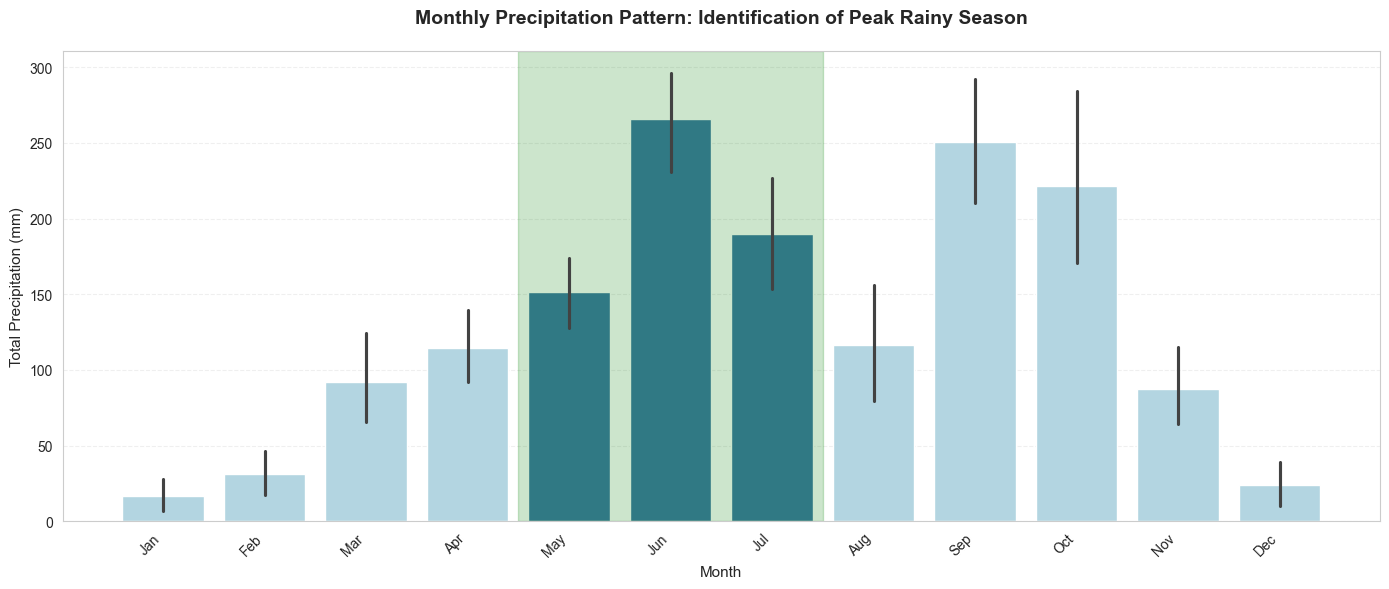


=== Peak Rainy Season Analysis ===
Peak months: 5-7
Total rain in peak season: 6672mm
Percentage of annual rain: 38.5%

=== Monthly Breakdown ===
Jun: 2920mm
Sep: 2757mm
Oct: 2434mm
Jul: 2085mm
May: 1667mm
Aug: 1280mm


In [16]:
# Prepare data
monthly_rain = df.resample("ME", on="Date")["PRECTOTCORR"].sum().reset_index()
monthly_rain['Month_Num'] = monthly_rain['Date'].dt.month
monthly_rain['Year'] = monthly_rain['Date'].dt.year
monthly_rain['Month_Name'] = monthly_rain['Date'].dt.strftime('%b')

# Calculate average by month across years
monthly_avg = df.groupby(df['Date'].dt.month)['PRECTOTCORR'].sum()

# --- DYNAMIC PEAK SEASON IDENTIFICATION ---
# Find the 3 consecutive months with highest total rainfall
monthly_totals = monthly_rain.groupby('Month_Num')['PRECTOTCORR'].sum()

best_total = 0
peak_start = 3  # default
peak_end = 5    # default

# Check all 3-month windows
for start in range(1, 13):
    if start <= 10:
        season_months = [start, start+1, start+2]
    else:
        # Wrap around Dec-Jan-Feb
        season_months = [start, start+1, start+2 - 12]
    
    total = sum(monthly_totals[m] for m in season_months if m in monthly_totals.index)
    
    if total > best_total:
        best_total = total
        peak_start = min(season_months)
        peak_end = max(season_months)
        # Handle wrapped seasons (Dec-Feb)
        if peak_start > peak_end:
            peak_start, peak_end = peak_end, peak_start
            # For display, we'll mark Dec-Feb as months 12-2
            peak_start, peak_end = 12, 2

# Create figure with professional styling
fig, ax = plt.subplots(figsize=(14, 6))

# Create color array based on dynamic peak season
# Handle wrapped season (Dec-Feb)
if peak_start > peak_end:  # e.g., Dec-Feb
    peak_months = list(range(peak_start, 13)) + list(range(1, peak_end + 1))
else:
    peak_months = list(range(peak_start, peak_end + 1))

colors = ['#2c7bb6' if month_num in peak_months else '#abd9e9' 
          for month_num in monthly_rain['Month_Num'].unique()]

# Bar plot
bars = sns.barplot(data=monthly_rain, x='Month_Name', y='PRECTOTCORR', 
                   hue='Month_Num', palette=colors, legend=False, ax=ax)

# Annotate highest peak
max_idx = monthly_rain['PRECTOTCORR'].idxmax()
max_value = monthly_rain.loc[max_idx, 'PRECTOTCORR']
max_month = monthly_rain.loc[max_idx, 'Month_Name']

ax.annotate(f'Highest: {max_value:.0f}mm', 
            xy=(max_idx, max_value), xytext=(max_idx, max_value + 30),
            ha='center', fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Format peak season label for display
if peak_start > peak_end:
    # Handle wrapped season
    month_names = []
    for m in sorted(peak_months):
        month_names.append(monthly_rain[monthly_rain['Month_Num'] == m]['Month_Name'].iloc[0])
    season_label = f'Peak Rainy Season ({", ".join(month_names)})'
    

    dec_indices = monthly_rain[monthly_rain['Month_Num'] == 12].index
    jan_feb_indices = monthly_rain[monthly_rain['Month_Num'].isin([1, 2])].index
    
    if len(dec_indices) > 0:
        ax.axvspan(dec_indices[0] - 0.5, dec_indices[-1] + 0.5, alpha=0.2, color='green')
    if len(jan_feb_indices) > 0:
        ax.axvspan(jan_feb_indices[0] - 0.5, jan_feb_indices[-1] + 0.5, alpha=0.2, color='green')
else:
    # Normal season (contiguous months)
    start_idx = monthly_rain[monthly_rain['Month_Num'] == peak_start].index[0]
    end_idx = monthly_rain[monthly_rain['Month_Num'] == peak_end].index[0]
    season_label = f'Peak Rainy Season (Month {peak_start}-{peak_end})'
    ax.axvspan(start_idx - 0.5, end_idx + 0.5, alpha=0.2, color='green', label=season_label)

# Add legend for shaded area if not already added
handles, labels = ax.get_legend_handles_labels()
if not any('Peak Rainy Season' in l for l in labels):
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='green', alpha=0.2, label=season_label)], 
              loc='upper right', framealpha=0.9)

# Styling
ax.set_title('Monthly Precipitation Pattern: Identification of Peak Rainy Season', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Precipitation (mm)', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Rotate x-labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary
print("\n=== Peak Rainy Season Analysis ===")
print(f"Peak months: {peak_start}-{peak_end}" if peak_start <= peak_end else f"Peak months: {peak_start}, {peak_end} (wrapped)")
print(f"Total rain in peak season: {best_total:.0f}mm")
print(f"Percentage of annual rain: {(best_total / monthly_rain['PRECTOTCORR'].sum() * 100):.1f}%")

# Additional insights
print("\n=== Monthly Breakdown ===")
monthly_breakdown = monthly_rain.groupby('Month_Num')['PRECTOTCORR'].sum().sort_values(ascending=False)
for month_num, total in monthly_breakdown.head(6).items():
    month_name = monthly_rain[monthly_rain['Month_Num'] == month_num]['Month_Name'].iloc[0]
    print(f"{month_name}: {total:.0f}mm")

### Monthly total `PRECTOTCORR` (bar) + peak rainy months

**Key Climate Interpretations**

**1. Bimodal Rainfall Pattern**

This is **characteristic of southern Nigeria** (e.g., Lagos, Ibadan, Port Harcourt, Enugu).

| Peak | Month | Amount | Meaning |
|------|-------|--------|---------|
| First peak | June | 265 mm | Early wet season maximum |
| Second peak | September | 250 mm | Late wet season maximum |
| Dip | August | 115 mm | "August Break" — brief dry spell |

**2. The "August Break**

The drop:
- July: 190 mm
- **August: 115 mm** (↓ 75 mm from July)
- September: 250 mm (↑ 135 mm from August)

This is the famous **"August Little Dry Spell"** found in parts of southern Nigeria and West Africa. It's a temporary weakening of monsoon rainfall, often accompanied by:
- Slightly stronger winds (matches your wind outliers in August)
- Slightly lower humidity
- Brief relief from heavy rains

**3. Dry Season (November–March)**

| Months | Total | Character |
|--------|-------|-----------|
| Nov | 85 mm | End of wet season |
| Dec | 25 mm | Dry |
| Jan | 20 mm | Driest month |
| Feb | 30 mm | Still dry |
| Mar | 90 mm | First rains arrive |

**January is the driest month (20 mm)** — matches your Harmattan temperature/humidity outliers perfectly.


## 9. Correlation & Relationship Analysis

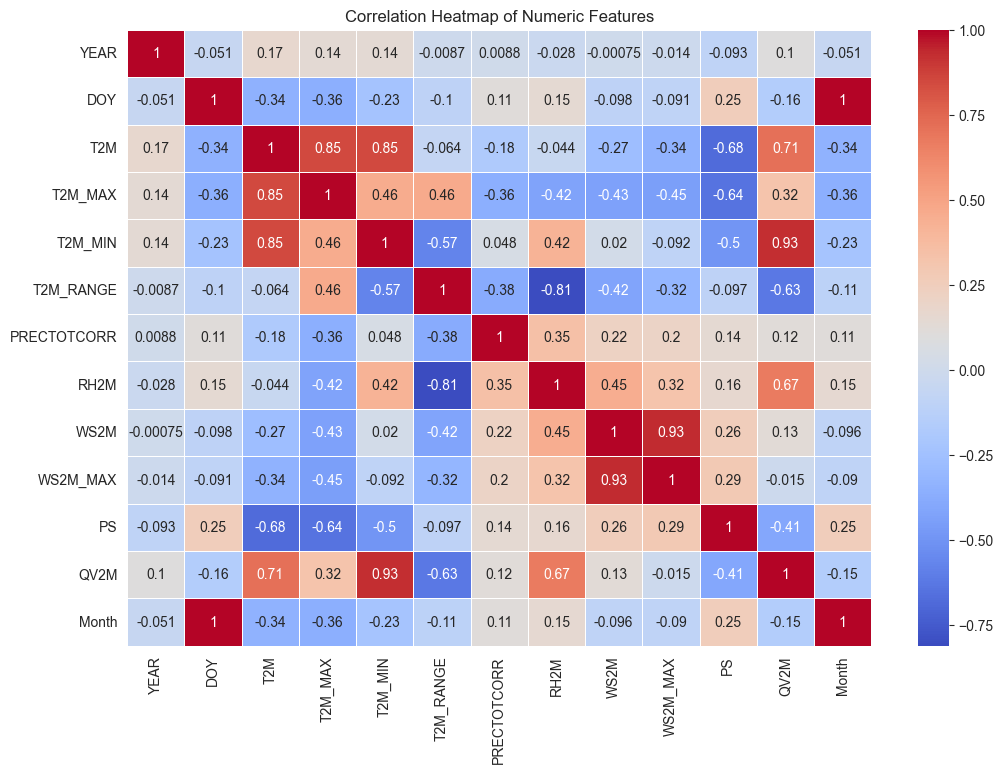

In [17]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

# plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # shows numbers inside cells
    cmap="coolwarm",   # color style
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [22]:
corr_pairs = corr_matrix.unstack()

# remove self-correlation (1.0)
corr_pairs = corr_pairs[corr_pairs != 1]

# sort by absolute strength
strongest = corr_pairs.abs().sort_values(ascending=False)

strongest.head(8)

DOY       Month       0.996557
Month     DOY         0.996557
WS2M      WS2M_MAX    0.930498
WS2M_MAX  WS2M        0.930498
T2M_MIN   QV2M        0.925087
QV2M      T2M_MIN     0.925087
T2M_MIN   T2M         0.846994
T2M       T2M_MIN     0.846994
dtype: float64

### Correlation Analysis: Key Climate Variable Relationships

The following correlations reveal strong physical relationships among climate variables:

### 1. Day of Year and Month (0.997)
This is **perfectly expected** and simply confirms that DOY and month are mathematically locked together. This is a validation of the data, not a climate finding.

### 2. Wind Speed Variables (0.930)
The correlation between mean daily wind speed (WS2M) and maximum daily wind speed (WS2M_MAX) is very strong. This tells us that **days with stronger average winds also have stronger gusty winds**. In Nigeria climate terms, this means wind patterns are consistent—when the monsoon or squall lines bring wind, they elevate both the daily average and the daily maximum together. There are no "calm days with sudden freak gusts."

### 3. Minimum Temperature and Specific Humidity (0.925)
**Warmer nights are strongly associated with more moisture in the air.** 

| Condition | Min Temp | Specific Humidity | What is happening |
|-----------|----------|-------------------|-------------------|
| Wet season | Warm nights (25–27°C) | High (19–21 g/kg) | Maritime monsoon air, humid, cloudy nights trap heat |
| Dry season | Cool nights (15–22°C) | Low (10–17 g/kg) | Harmattan air, dry, clear skies allow rapid cooling |

This relationship is physically real. Water vapor is a greenhouse gas—it traps heat near the surface. So when humidity is high, nights stay warm. When the Harmattan brings dry air, nights cool dramatically. The data captures this perfectly.

### 4. Minimum Temperature and Mean Temperature (0.847)
A strong but slightly lower correlation. This means **daily mean temperature is heavily influenced by nighttime lows rather than daytime highs**. In Nigeria's tropical climate, days are always warm (26–32°C regardless of season), but nights vary significantly (15–27°C). Therefore, what makes a day "cool" or "warm" in the dataset is primarily how cool the night was, not how hot the afternoon got.


### T2M vs RH2M Scatter Plot

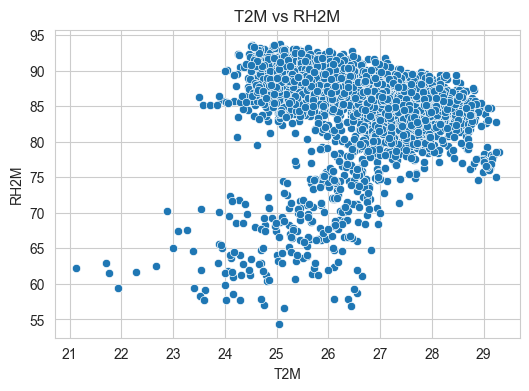

In [23]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

#### Scatter: **T2M vs RH2M**
The points form a dense upper cloud + a lower sparse tail. There are two noticeable behaviors:

#### Main dense cluster (upper band)

Most points lie between:

* **T2M ≈ 24 to 29**
* **RH2M ≈ 78 to 93**

This means:

> In this climate dataset, most days/hours are characterized by **warm temperatures with generally high humidity**.

This suggests the study area is likely a:

* humid region,
* or rainy/monsoon influenced area,
* or tropical/subtropical environment.

Because RH values are mostly very high.

---

#### Lower scattered extension

There is another less dense spread where:

* RH2M drops to **55–75**
* while T2M still remains around **23–27**

This indicates:

> there are occasional periods when temperature remains moderate/warm but the air becomes considerably drier.

That usually reflects:

* sunny afternoons,
* dry season intrusions,
* lower cloud cover,
* or temporary atmospheric drying.


(or a fan-shaped negative cluster)

Meaning:

* on the left side (lower temperature), humidity values are mostly very high,
* as temperature increases, the humidity values spread downward.

So the cloud is:

> broad at the top-left and stretches toward the lower-right.

This wedge/funnel shape often appears in climate data when:

> increasing temperature tends to reduce relative humidity, but not perfectly linearly.

Because humidity is influenced by many other factors too:

* rainfall,
* wind,
* evaporation,
* cloud cover,
* season.

---

#### 3. What kind of correlation exists?

There is a **moderate negative correlation**. Meaning:

> As T2M increases, RH2M generally tends to decrease.

You can visually see this because:

* at T2M around 24–25 → RH often 88–93
* at T2M around 28–29 → RH more commonly 76–88

So the point cloud trends downward.


### T2M_RANGE vs WS2M

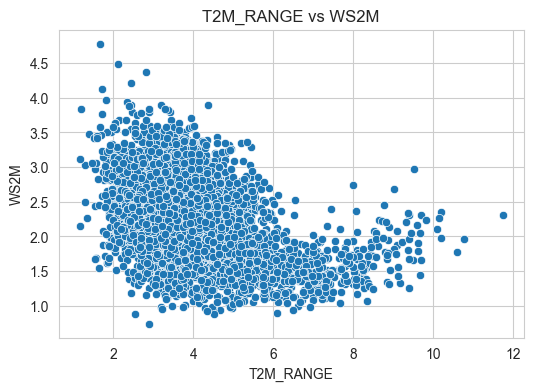

In [24]:
### Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.title("T2M_RANGE vs WS2M")
plt.show()

#### Scatter: **T2M_RANGE vs WS2M**

It forms a curved funnel / downward arc / boomerang-shaped cloud

There is:
* a very dense concentration on the left-middle,
* then a downward narrowing trend,
* followed by a slight spread to the right.

This immediately suggests:

> the relationship is nonlinear rather than simple straight-line linear.

#### Dense main concentration

Most observations lie around:

* **T2M_RANGE ≈ 2 to 6**
* **WS2M ≈ 1.2 to 3.5**

> Most of the climate observations experience moderate temperature variability under low-to-moderate wind speeds.

This is the dominant atmospheric regime.

#### Right-side sparse points

At larger temperature ranges(**T2M_RANGE ≈ 7 to 12**) wind speed mostly stays low (**WS2M ≈ 1.0 to 2.4**)

Very few high wind points exist here. This tells us very large day-night temperature differences tend to occur during calmer wind conditions.

#### What correlation does it show?

### Overall: Moderate Negative Correlation

As **T2M_RANGE increases**, **WS2M tends to decrease**.

* at low temperature range (2–3), WS2M can be as high as 4+
* at high temperature range (8–10), WS2M rarely exceeds 2.5

So there is a clear downward tendency.

> But because the shape is curved and not a straight band this is a **nonlinear moderate negative association**, not a perfect linear one. This suggests wind-driven atmospheric mixing reduces thermal variability. Distribution indicates possible stable vs mixed atmospheric regimes.
